# Brainstorm with ChatGPT

Dynamics on networks can be modelled by means of network automata. We study in particular binary outer-totalistic network automata, i.e. a topological generalisation of life-like cellular automata. Within this model, we will study dynamical perturbations: investigating how small changes to the initial configuration will propagate through the system, potentially affecting the emergent behaviour of the entire system. In particular, we study the relationship between structural properties and dynamical properties, which is to say that we want to find a relationship between node properties and defect propagation. For example, it is to be expected that nodes that are highly connected (with a high degree) will more easily transmit a defect, than nodes that are barely connected (low degree).

**1. What kinds of networks are we considering?**

>We will at first consider lattice graphs that increasingly move towards random graphs by increasing the rewiring probability.

That's a good idea. Note that this will also clearly affect some global network properties, such as average path length. Some suggested metrics are clustering coefficient and defect propagation entropy.

**2. What is the rule space for our binary outer-totalistic automata?**

> The rule space is a generalisation of Life-like cellular automata, called Life-like network automata.

Make sure to relate this to (more recent) papers on "graph cellular automata"

**3. How are we defining a "defect"?**

> A defect is a single toggled node: 0 becomes a 1 or vice versa. It is always applied at time step 0.

Interesting metrics here include (i) defect propagation speed, (ii) time-to-equilibrium, and (iii) perturbation basin (set of nodes eventually affected)

**4. What metrics will we use to quantify the propagation of a defect?**

> We will consider the number of affected nodes over time (that's the most straightforward), but we could also consider the defect entropy or the Lyapunov exponent. As long as it can be related to the perturbation in a single node.

We should define a Lyapunov exponent for each node (only flipping that node, and averaging over various initial configurations). ChatGPT suggests working with the Jensen-Shannon divergence. 

**5. How will we relate node properties to defect propagation?**

> We prefer simple and interpretable properties on the node level, and also prefer properties that are unique and impose a clear order (like Pagerank).

PageRank accounts for both degree and position in the network, so this makes sense. We should definitely compare PageRank, degree, closeness, betweenness, and k-core index. Centrality refers to a measure that assigns importance or influence to nodes. We could define a new concept which we may call "defect centrality", which is a dynamical counterpart of the structural centrality measures.

Important: a very influential work is called "Identification of influential spreaders in complex networks" (in Nature).

**6. Are the network topologies static or dynamic?**

> The topologies are static.

We could further identify some global network measures (even though they do not say something about the node level).

**7. How will we sample or generate initial configurations?**

> We will start with a random initial state with a fixed overall density (so exactly half of the nodes are in one state, and the other half in the other).

It is definitely interesting to compare random vs. structured seeds, e.g. seeds in which nodes in the same community start off with the same initial configuration.

**8. What role does stochasticity play in our model, if any?**

> The dynamics are purely deterministic.

This guarantees that all observed randomness coems from the structure and the initial configuration, which is easier in terms of analysis. We should use a bifurcation diagram to show phase transitions.

**9. What kinds of emergent behaviour are we hoping to identify or characterise?**

> We hope to identify the node property that has the highest predictive value for defect propagation. In other words, we want to find the node that has the highest impact on the emergent dynamical behaviour.

**10. Do we envision potential applications or analogies in real-world systems?**

> The clearest example is social contagion: opinion spread models. This may address for example the question "which community should I target in order to affect the election outcome?"



# Additional ideas and remarks

1. The standard idea is to introduce defects based on the structural node properties. However, defects may also be introduced based on the properties of the initial configuration. For example, if the initial configuration generates a locally highly dense region (a clique in which all nodes have the same state), it may be interesting to target the central node specifically _in this clique_. This is what I mean with a dynamically inspired targeted defect: it depends on the states, not (only) on the structure. This is known as "structural targeting" versus "contextual targeting"

2. Instead of using the Lyapunov exponent (which does not make a whole lot of sense for our purpose), we could trace (i) the defect size over time, (ii) the cumulative defect over time, or (iii) the defect trace entropy. This would depend on the node that was originally perturbed.

3. Like in the Nature Physics paper, we could consider the $k$-shell decomposition of the network, and consider the influence of nodes based on this distinction. In `igraph` this is the `coreness()` method. The $k$-shell decomposition is not really useful when considering random networks or small-world networks, as most of the nodes will have large coreness (there is no real distinction). Mental note: think about "pruning" the network.

4. Important difference with the Nature Physics paper is that we will mostly consider damage spread, not state spread (although both would probably be interesting). Importantly, they only study the SIS and SIR model. Our model is much more general.

5. Particular network types have a small core. Random graphs and small-world graphs certainly do _not_ have a small core. Scale-free networks and tree/hierarchy networks also not really. Networks can be made especially for this purpose: core-periphery networks. In these networks, the core is strongly connected with itself.

6. The betweenness measure appears to be a bad predictor of viral spread! That's new. Also the node degree is not a great predictor, and there is a strong correlation between node degree and PageRank. Also the Nature paper says that a high node degree is not a property that the "driver nodes" necessarily have.

7. It appears that the $k$-shell strategy is only relevant when multiple seeds are chosen (over 2 percent of all nodes). Otherwise, the degree is an equally good predictor.

8. Another interesting metric to study is the **persistence**, which is the probability (over time) that a particular node becomes infected. And the imprecision function may be useful to check how good a structural property is at predicting certain dynamical behaviour.

9. Erkol et al. (2019) made a big comparison of many properties and how they are correlated with spreading on networks. They find that simple metrics like adaptive degree and closeness centrality can already tell us a lot about the potential for spreading. Does this contradict the paper in Nature Physics?

10. Definitely interesting is the Gates and Rocha paper from 2016, where they highlight that dynamical properties are also important for controlling complex networks (not just structure).

# Possible research questions

1. Following the Nature Physics paper: is the $k$-shell measure also a robust indicator for the spreading efficiency for all non-equivalent LLNAs
    - We would need to study this in networks that have a variety of $k_s$ values, that ideally do not correlate too much with the degree $k$.
    - Make a clear distinction between seeding (as is done in the paper) and damaging (which is not treated). Note that the SIS model will always allow some spreading, while a number of LLNA rules will just always die out immediately.
    - Note that the situation is quite different when we impose multiple seeds at the same time

2. Establish a link between Extreme Learning Machines and influence maximisation in Network Automata. There might be something there.

3. Instead of changing a node's value in the very start, and then having it run along, we could also experiment with "pinning control", which means that a node's value is fixed over time. This represents for example a political agent whose opinion cannot be changed under any circumstances, and which may be mobilised to target a particular community. There is a whole literature around this (see refs. in Parmer 2022). I could then use the algorithm that is proposed in that work, to look for the set of nodes that are the most influential on dynamical grounds.

4. As is mentioned in Parmer 2022 in the end: "our definition of dynamical influence and our algorithm for the selection of optimal driver sets can be extended to study the effect of short-term perturbations, i.e., the state of the seeds is only initially set to a given value but can be altered by the dynamics of the network."

In [2]:
# standard preamble for the Notebooks I use
import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams

# Enable LaTeX and set Times New Roman as the font
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: Use LaTeX packages
})

from tqdm import tqdm

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

# compact saving of data
import h5py

from src.automata import LLNA
from src.simulation import *
from src.rules import binary_indices, return_equivalent_rule, get_nonequiv_rules, return_life_like_dict
from src.networks import create_2d_torus_lattice, watts_strogatz_rewire
from src.analysis import median_and_percentiles_over_ensemble

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# The Anneal Life-like CA/NA

## Inspect the update diagram

This rule is equivalent to itself.


(<Figure size 1000x180 with 1 Axes>,
 <Axes: title={'center': 'Diagram for LLNA $\\phi^{9}_{464,488}$'}, xlabel="State density $\\rho$ of the node's neighbourhood", ylabel='Node becomes ...'>)

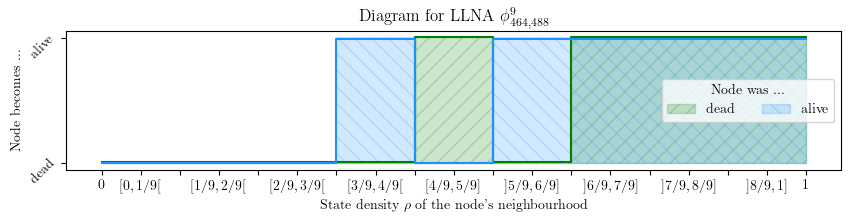

In [6]:
life_like_dict = return_life_like_dict()
life_like_name = 'anneal'

resolution = 9
beta, sigma = life_like_dict[life_like_name]
B_set = binary_indices(beta)
S_set = binary_indices(sigma)

# this rule is equivalent to itself
beta_equiv, sigma_equiv = return_equivalent_rule(resolution, B_set, S_set, return_decimals=True)
if (beta, sigma) == (beta_equiv, sigma_equiv):
    print("This rule is equivalent to itself.")

model = LLNA(resolution, B_set, S_set, iso=True)
model.diagram()

## Inspect the mean-field curve and the Derrida curve

## Inspect some typical behaviour in a video

In [11]:
VISUALISE=False

# Parameters
width = 100                  # Grid size (L x L) WATCH OUT with values, becomes intensive fast
num_nodes = width**2
rewiring_prob = 0.2     # Rewiring probability
degree = 8
num_edges = num_nodes*degree//2

# Create toroidal lattice and rewire.
# REWIRING CAN TAKE A WHILE!
lattice_graph = create_2d_torus_lattice(width, degree=degree)
small_world_graph = watts_strogatz_rewire(lattice_graph, rewiring_prob)
random_graph = ig.Graph.Erdos_Renyi(n=num_nodes, m=num_edges) # watts_strogatz_rewire(lattice_graph, 1.)

# find edges
lattice_graph.to_directed()
lattice_edges = tc.tensor(lattice_graph.get_edgelist()).T
lattice_graph.to_undirected()

small_world_graph.to_directed()
small_world_edges = tc.tensor(small_world_graph.get_edgelist()).T
small_world_graph.to_undirected()

random_graph.to_directed()
random_edges = tc.tensor(random_graph.get_edgelist()).T
random_graph.to_undirected()

# save graphs and edges in list
graphs = [lattice_graph, small_world_graph, random_graph]
graph_names = ["Lattice", f"Small World ($p={rewiring_prob}$)", "Random"]
edges = [lattice_edges, small_world_edges, random_edges]

if VISUALISE:
    # Optional: Visualize
    fig, axs = plt.subplots(1,3,figsize=(15,5))
    layout = lattice_graph.layout("grid")  # Grid layout
    vertex_size  = 5
    edge_width = 0.5
    fontsize = 22

    for ax, graph, name in zip(axs, graphs, graph_names):
        ig.plot(graph, layout=layout, vertex_size=vertex_size, edge_width=edge_width, target=ax)
        ax.set_title(name, fontsize=fontsize)

In [40]:
def init_config_with_dens(N, dens):
    # defines a random initial configuration with a fixed state density
    s0 = np.zeros(N, dtype=int)
    s0[:np.round(dens*N).astype(int)] = 1.
    np.random.shuffle(s0)
    return s0

T = 200
num_config = 10
init_dens = 0.5

init_configs = np.array([init_config_with_dens(num_nodes, init_dens) for _ in range(num_config)])
# init_defects = np.array([init_config_with_dens(L*L, 1/L/L) for _ in range(num_config)])
# init_configs_defect = (init_configs + init_defects) % 2
# run simulation over a number of time steps
configs = model.forward(small_world_edges, tc.tensor(init_configs), T=T).numpy().astype(int)
# configs_defect = model.forward(lattice_edges, tc.tensor(init_configs_defect), T=T).numpy().astype(int)
# defects = (configs + configs_defect) % 2

# put back in L x L shape 
configs = configs.reshape((num_config, T+1, width, width))
# defects = defects.reshape((num_config, T+1, L, L))

In [43]:
# animations
import matplotlib.animation as animation
from IPython.display import HTML

def make_animation_object(grids, title=None):
    # Set up figure
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(grids[0])
    # Update function for animation
    def update(frame):
        im.set_array(grids[frame])
        ax.set_title(title, fontsize=16)
        ax.set_xticks([]); ax.set_yticks([])
    # Create animation
    ani = animation.FuncAnimation(fig, update, frames=T+1, interval=100)
    plt.close()
    return ani

In [46]:
# show an animation

example_idx = np.random.randint(num_config)
ani = make_animation_object(configs[example_idx])
# ani = make_animation_object(defects[example_idx])

# show inline
HTML(ani.to_jshtml())

In [42]:
# save some GIFs for future reference

SAVEGIFS = True

if SAVEGIFS:
    for i, config in tqdm(enumerate(configs), total=configs.shape[0]):
        savename = f"animation_llna_smallworld_{life_like_name}_{width}x{width}_T{T}_sample{i}.gif"

        # example_idx = np.random.randint(num_config)
        ani = make_animation_object(config)
        # ani = make_animation_object(defects[example_idx])

        # Save animations as GIFs
        loc = '../figures/gifs/'
        ani.save(loc+savename, writer='pillow', fps=16)  # Using Pillow

        # show inline
        # HTML(ani.to_jshtml())

100%|██████████| 10/10 [01:12<00:00,  7.21s/it]
